
## Introduction
---
As a machine learning engineer working for a social media company, your responsibility is to assess whether songs shared on the platform are suitable for children. Since evaluating every song using large language models (LLMs) is computationally expensive, an alternative approach using Retrieval-Augmented Generation (RAG) is introduced.

RAG works by combining a retrieval component, which finds relevant information (such as embeddings of previously answered questions about content safety), with a generation component that uses this retrieved context to make predictions about new songs. This method allows the system to scale efficiently while still ensuring that each song is properly evaluated for child safety, without needing to run a full LLM inference for every single case.

---

### Import Libraries

In [1]:
import torch
import re
import numpy as np
import torch.nn as nn
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from transformers import BertTokenizer, BertModel


### Helper Function

In [2]:
def tsne_plot(data, plot):
    
    tsne = TSNE(n_components=3, random_state=42, perplexity=min(50, data.shape[0]-1))
    data_3d = tsne.fit_transform(data)
    
    fig = plt.figure(figsize=(8,8))
    ax = fig.add_subplot(111, projection='3d')
    
    color = plt.cm.rainbow(np.linspace(0,1,len(data_3d)))
    
    for idx, point, in zip(range(len(data_3d)), data_3d):
        ax.scatter(point[0], point[1], point[2], color= color[idx], label = f'{plot} {idx+1}')
    
    ax.set_xlabel("TSNE component 1")
    ax.set_ylabel("TSNE Component 2")
    ax.set_zlabel("TSNE Component 3")
    
    plt.title("3D-TSNE Visualization of "+ plot+ " Embeddings")
    plt.legend(title = plot + "index", bbox_to_anchor = (1.05,1), loc = 'upper left')
    plt.show()

### Tokenizer and Model

In [3]:
model_name = 'bert-base-uncased'
tokenizer = BertTokenizer.from_pretrained(model_name)

We consider the input as a list of tuple

In [4]:
# Input text to get embeddings for
input_text = ["This is an example sentence for BERT embeddings.", "How do you like it ","There are other models"]

We use **batch_encode_plus** method for tokenizing the text. It automatically handles the padding and truncation to ensure uniformity in input length, which is difficult for batch processing like BERT models.

In [5]:
tokenized_input = tokenizer(input_text, padding=True, truncation=True, add_special_tokens=True)
tokenized_input

{'input_ids': [[101, 2023, 2003, 2019, 2742, 6251, 2005, 14324, 7861, 8270, 4667, 2015, 1012, 102], [101, 2129, 2079, 2017, 2066, 2009, 102, 0, 0, 0, 0, 0, 0, 0], [101, 2045, 2024, 2060, 4275, 102, 0, 0, 0, 0, 0, 0, 0, 0]], 'token_type_ids': [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], 'attention_mask': [[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0], [1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]]}

In [6]:
tokenized_input['input_ids'][0]

[101,
 2023,
 2003,
 2019,
 2742,
 6251,
 2005,
 14324,
 7861,
 8270,
 4667,
 2015,
 1012,
 102]

In [7]:
# confirm tokenization by verification
decode_input = tokenizer.decode(tokenized_input['input_ids'][0])
decode_input

'[CLS] this is an example sentence for bert embeddings. [SEP]'

In [8]:
print(f"length {len(decode_input.split())}")

length 10


In [9]:
## Define Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device.type

'cuda'

In [10]:
input_ids_tensor = torch.tensor(tokenized_input['input_ids']).to(device)
attention_tensor = torch.tensor(tokenized_input['attention_mask']).to(device)
input_ids_tensor, attention_tensor

(tensor([[  101,  2023,  2003,  2019,  2742,  6251,  2005, 14324,  7861,  8270,
           4667,  2015,  1012,   102],
         [  101,  2129,  2079,  2017,  2066,  2009,   102,     0,     0,     0,
              0,     0,     0,     0],
         [  101,  2045,  2024,  2060,  4275,   102,     0,     0,     0,     0,
              0,     0,     0,     0]], device='cuda:0'),
 tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
         [1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0],
         [1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]], device='cuda:0'))

In [11]:
model = BertModel.from_pretrained(model_name)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [12]:
model.to(device)

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

In [13]:
word_embeddings = model(input_ids_tensor, attention_tensor)
word_embeddings

BaseModelOutputWithPoolingAndCrossAttentions(last_hidden_state=tensor([[[-0.3137, -0.3394, -0.3190,  ..., -0.6073,  0.0885,  0.8370],
         [-0.7485, -0.5191, -0.5937,  ..., -0.3184,  0.7032,  0.2263],
         [-0.4606, -0.7230,  0.0426,  ..., -0.0821,  0.3424,  0.7808],
         ...,
         [-0.3740, -0.2744, -0.3737,  ..., -0.3573, -1.0819,  0.4773],
         [ 0.6473,  0.1670, -0.6649,  ...,  0.3043, -0.6731, -0.3639],
         [ 0.5446,  0.1987, -0.4165,  ...,  0.5330, -1.0449, -0.2541]],

        [[ 0.0442, -0.0223, -0.1309,  ..., -0.3127,  0.1546,  0.2099],
         [ 0.5894, -0.1005,  0.3338,  ...,  0.3478,  0.3881,  0.1619],
         [ 0.3529, -0.2993, -0.0435,  ..., -0.4312,  0.4435, -0.1076],
         ...,
         [-0.2295, -0.3750,  0.1175,  ...,  0.1012,  0.3366, -0.2242],
         [-0.0865,  0.1097,  0.5585,  ...,  0.0693,  0.0152, -0.0016],
         [-0.1374,  0.0058,  0.5085,  ...,  0.0897,  0.1203, -0.1320]],

        [[-0.1595,  0.0046,  0.1481,  ..., -0.0987,  

In [14]:
word_embeddings[0].squeeze()

tensor([[[-0.3137, -0.3394, -0.3190,  ..., -0.6073,  0.0885,  0.8370],
         [-0.7485, -0.5191, -0.5937,  ..., -0.3184,  0.7032,  0.2263],
         [-0.4606, -0.7230,  0.0426,  ..., -0.0821,  0.3424,  0.7808],
         ...,
         [-0.3740, -0.2744, -0.3737,  ..., -0.3573, -1.0819,  0.4773],
         [ 0.6473,  0.1670, -0.6649,  ...,  0.3043, -0.6731, -0.3639],
         [ 0.5446,  0.1987, -0.4165,  ...,  0.5330, -1.0449, -0.2541]],

        [[ 0.0442, -0.0223, -0.1309,  ..., -0.3127,  0.1546,  0.2099],
         [ 0.5894, -0.1005,  0.3338,  ...,  0.3478,  0.3881,  0.1619],
         [ 0.3529, -0.2993, -0.0435,  ..., -0.4312,  0.4435, -0.1076],
         ...,
         [-0.2295, -0.3750,  0.1175,  ...,  0.1012,  0.3366, -0.2242],
         [-0.0865,  0.1097,  0.5585,  ...,  0.0693,  0.0152, -0.0016],
         [-0.1374,  0.0058,  0.5085,  ...,  0.0897,  0.1203, -0.1320]],

        [[-0.1595,  0.0046,  0.1481,  ..., -0.0987,  0.2391,  0.3857],
         [-0.2603, -0.0485,  0.0093,  ..., -0

### Generating Mean-Pooled BERT Embeddings for RAG

In this step, you will compute aggregated mean embeddings for input sequences using the previously loaded BERT model. For each input, token IDs and attention masks are processed to extract embeddings only from non-padded tokens. These token-level embeddings are then averaged to produce a single vector representation per sequence.

The final output is a tensor containing mean embeddings for all sequences. This provides compact yet meaningful representations of the inputs, which can be used for tasks such as clustering, similarity search, or as features for downstream models. Each document should be limited to a maximum of 512 tokens.


In [15]:
def aggregate_embeddings (input_ids, attention_mask, model:BertModel):
    
    mean_embeds = []
    
    for input_ids, mask in tqdm(zip(input_ids, attention_mask)):
        
        input_ids_tensor = torch.tensor([input_ids]).to(device)
        mask_tensor = torch.tensor([mask]).to(device)
        
        with torch.no_grad():
            word_embeds = model(input_ids_tensor, mask_tensor)[0].squeeze(0)
            
            #filter out valid embeddings by valid embed mask
            valid_embed_mask = mask_tensor[0] != 0
            
            valid_embeddings = word_embeds[valid_embed_mask]
            
            #we get the mean 
            valid_embeddings = valid_embeddings.mean(dim=0)
            mean_embeds.append(valid_embeddings.unsqueeze(0))
        
    aggregate_mean_embeds = torch.cat(mean_embeds)
    return aggregate_mean_embeds 
            

### Define Input Text to Embedings Function

In [16]:
def txt_to_embeds (input, max_input = 512):
    
    input_tokens = tokenizer(input, padding=True, truncation=True, max_length=max_input)
    question_embeddings = aggregate_embeddings(input_tokens['input_ids'], input_tokens['attention_mask'],model)
    return question_embeddings

### Convert questions and the song lyrics into embeddings

In [17]:
# pattern match and text processing using 're'
def text_filter (text):
    
    new_text = re.sub(r'\n'," ", text)
    
    #filter the single quotes
    new_text = [new_text.replace("'","")]
    
    return new_text

In [18]:
song_questions = [
    "Does this song contain any violent themes, such as references to guns, killing, or physical aggression? Example: Does the song describe or promote physical violence, like fighting or shootings?",
    "Are there any explicit lyrics or bad words used in this song that might be considered offensive or inappropriate? Example: Does the song use language commonly recognized as profanity or derogatory terms?",
    "Is the overall content of this song suitable for children, considering its themes, language, and messages? Example: Are there elements in the song that could be deemed too mature or unsuitable for young listeners?",
    "Does this song explicitly mention weapons, such as guns, knives, or other similar items? Example: Are specific types of weapons described or glorified in the lyrics?",
    "Are the messages conveyed in this song positive and uplifting for children? Example: Does the song promote values like kindness, friendship, and positivity?",
    "Does this song include any sexual content, references to sexual behavior, or suggestive language? Example: Are there lyrics that explicitly or implicitly discuss sexual themes or experiences?",
    "Does this song offer any educational value, such as teaching the alphabet, basic math, or other learning content? Example: Are there educational segments in the song that could help children learn fundamental skills like the ABCs or counting?",
    "Does this song promote emotional resilience and social skills among children? Example: Does the song include themes of overcoming challenges or building friendships?"
]

Convert Text into Embeddings

In [19]:
ques_embeds = txt_to_embeds(song_questions)
ques_embeds, ques_embeds.shape

8it [00:00, 37.20it/s]


(tensor([[ 0.2607,  0.0980, -0.1515,  ..., -0.5265, -0.2586,  0.2193],
         [-0.2477,  0.1718, -0.1686,  ..., -0.4667, -0.1105,  0.3039],
         [-0.2005, -0.1769,  0.0132,  ..., -0.2890, -0.1553,  0.2023],
         ...,
         [ 0.0393,  0.1873, -0.2147,  ..., -0.4549, -0.2422,  0.5003],
         [-0.0068,  0.0293, -0.0152,  ..., -0.1871, -0.0219,  0.2906],
         [-0.2251, -0.0378, -0.0727,  ..., -0.3595, -0.0591,  0.0731]],
        device='cuda:0'),
 torch.Size([8, 768]))

In [20]:
ques_plot = ques_embeds.detach().cpu().numpy()

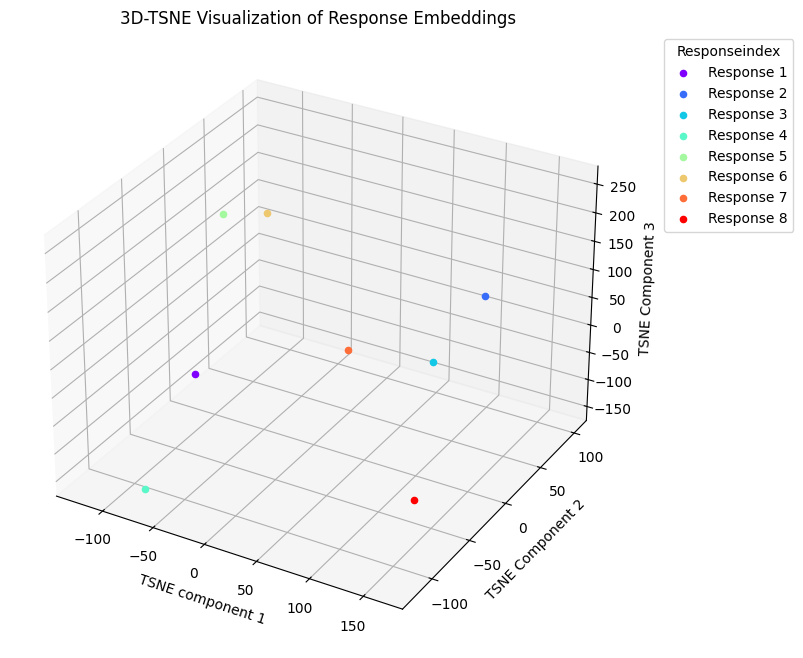

In [21]:
#plot the embeddings
tsne_plot(ques_plot,"Response")

Define Yes Response

In [22]:
yes_reponse = [
    "Yes, this song contains violent themes, including references to guns, killing, or physical aggression, and is not suitable for children.",
    "Yes, this song includes explicit lyrics or bad words that might be considered offensive or inappropriate for young audiences.",
    "No, the overall content of this song is not suitable for children as it includes themes, language, and messages that are too mature or unsuitable for young listeners.",
    "Yes, this song explicitly mentions weapons, such as guns and knives, which could be disturbing or inappropriate for children’s entertainment.",
    "Yes, the messages conveyed in this song are positive and uplifting, promoting values like kindness, friendship, and positivity, beneficial for children.",
    "Yes, this song includes sexual content and references to sexual behavior or suggestive language, which are inappropriate for a child-friendly environment.",
    "Yes, this song offers significant educational value, including segments that teach the alphabet, basic math, and other learning content, making it both fun and educational for children.",
    "Yes, this song promotes emotional resilience and social skills, incorporating themes about overcoming challenges and building friendships, which are essential for children's development."
]

In [23]:
def RAG_process (question, song, n_responses = 3):
    
    ques_embeds = txt_to_embeds(question)
    processed_song = text_filter(song)
    
    song_embeds = txt_to_embeds(processed_song)
    
    #dot product
    dot_product = ques_embeds @ song_embeds.T
    
    #reshape(flattern) the output
    dot_product = dot_product.reshape(-1)
    
    sorted_indices = torch.argsort(dot_product, descending=True)
    
    # sorted indices convert to a list
    sorted_list = sorted_indices.tolist()
    
    for item in sorted_list[:n_responses]:
        print(yes_reponse[item])
        

Test The RAG Pipeline:

In [24]:
my_shoe_lyrics="""Barney is a dinosaur from our imagination
And when he's tall
He's what we call a dinosaur sensation
Barney's friends are big and small
They come from lots of places
After school they meet to play
And sing with happy faces
Barney shows us lots of things
Like how to play pretend
ABC's, and 123's
And how to be a friend
Barney comes to play with us
Whenever we may need him
Barney can be your friend too
If you just make-believe him!"""

In [25]:
RAG_process(song_questions,my_shoe_lyrics)

8it [00:00, 24.39it/s]
1it [00:00, 52.63it/s]

Yes, this song offers significant educational value, including segments that teach the alphabet, basic math, and other learning content, making it both fun and educational for children.
Yes, this song includes explicit lyrics or bad words that might be considered offensive or inappropriate for young audiences.
Yes, the messages conveyed in this song are positive and uplifting, promoting values like kindness, friendship, and positivity, beneficial for children.


In [26]:
sesame_street = """
Sunny day
Sweepin' the clouds away
On my way to where the air is sweet
Can you tell me how to get
How to get to Sesame Street?

Come and play
Everything's A-okay
Friendly neighbors there
That's where we meet
Can you tell me how to get
How to get to Sesame Street?

It's a magic carpet ride
Every door will open wide
To happy people like you
Happy people like
What a beautiful

Sunny day
Sweepin' the clouds away
On my way to where the air is sweet
Can you tell me how to get
How to get to Sesame Street?
How to get to Sesame Street?
How to get to Sesame Street?
How to get to Sesame Street?
How to get to Sesame Street?
"""

In [27]:
RAG_process(song_questions,sesame_street)

8it [00:00, 27.21it/s]
1it [00:00, 52.64it/s]

Yes, the messages conveyed in this song are positive and uplifting, promoting values like kindness, friendship, and positivity, beneficial for children.
Yes, this song offers significant educational value, including segments that teach the alphabet, basic math, and other learning content, making it both fun and educational for children.
Yes, this song includes explicit lyrics or bad words that might be considered offensive or inappropriate for young audiences.
